In [3]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_b653d76d9ac1f70e699fcbe2ac562478"

In [8]:
!pip -q install kaggle

In [9]:
!kaggle datasets list -s skin-cancer9-classesisic

ref                                   title                   size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------  ----------------  ----------  --------------------------  -------------  ---------  ---------------  
nodoubttome/skin-cancer9-classesisic  Skin Cancer ISIC  1647873564  2019-08-26 18:59:21.257000          36188        317  0.75             


In [10]:
!kaggle datasets download -d nodoubttome/skin-cancer9-classesisic

Dataset URL: https://www.kaggle.com/datasets/nodoubttome/skin-cancer9-classesisic
License(s): other
100% 786M/786M [00:45<00:00, 18.1MB/s]



In [11]:
!unzip -q skin-cancer9-classesisic.zip -d /content/skin_cancer_dataset

In [12]:
import os

for root, dirs, files in os.walk("/content/skin_cancer_dataset"):
    print(root, len(files), "files")
    if len(files) > 0:
        print("Example files:", files[:5])

/content/skin_cancer_dataset 0 files
/content/skin_cancer_dataset/Skin cancer ISIC The International Skin Imaging Collaboration 0 files
/content/skin_cancer_dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Train 0 files
/content/skin_cancer_dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Train/squamous cell carcinoma 181 files
Example files: ['ISIC_0033295.jpg', 'ISIC_0029582.jpg', 'ISIC_0025069.jpg', 'ISIC_0029638.jpg', 'ISIC_0025247.jpg']
/content/skin_cancer_dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Train/pigmented benign keratosis 462 files
Example files: ['ISIC_0027310.jpg', 'ISIC_0025470.jpg', 'ISIC_0025076.jpg', 'ISIC_0026704.jpg', 'ISIC_0026290.jpg']
/content/skin_cancer_dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Train/actinic keratosis 114 files
Example files: ['ISIC_0033494.jpg', 'ISIC_0027452.jpg', 'ISIC_0026525.jpg', 'ISIC_0027172.jpg', 'ISIC_0029781.jpg']
/content/skin_cancer_

In [13]:
import os
import pandas as pd

# Main dataset path
dataset_path = "/content/skin_cancer_dataset/Skin cancer ISIC The International Skin Imaging Collaboration"

# Train and test folders
train_path = os.path.join(dataset_path, "Train")
test_path = os.path.join(dataset_path, "Test")

# Four classes selected for our project
selected_classes = [
    "melanoma",
    "basal cell carcinoma",
    "nevus",
    "pigmented benign keratosis"
]

print("Selected Classes:")
for i, class_name in enumerate(selected_classes, start=1):
    print(f"{i}. {class_name}")

Selected Classes:
1. melanoma
2. basal cell carcinoma
3. nevus
4. pigmented benign keratosis


In [14]:
# Count images in each selected class

train_counts = {}
test_counts = {}

for class_name in selected_classes:
    train_folder = os.path.join(train_path, class_name)
    test_folder = os.path.join(test_path, class_name)

    train_counts[class_name] = len([
        f for f in os.listdir(train_folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    test_counts[class_name] = len([
        f for f in os.listdir(test_folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

distribution_df = pd.DataFrame({
    "Class": selected_classes,
    "Train Images": [train_counts[c] for c in selected_classes],
    "Test Images": [test_counts[c] for c in selected_classes]
})

distribution_df

,Class,Train Images,Test Images
0,melanoma,438,16
1,basal cell carcinoma,376,16
2,nevus,357,16
3,pigmented benign keratosis,462,16


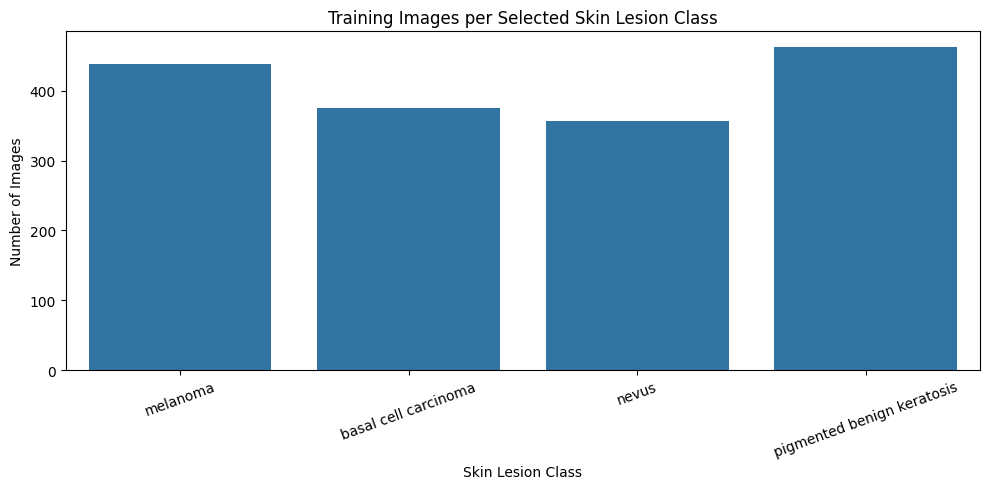

In [15]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=distribution_df,
    x="Class",
    y="Train Images"
)

plt.title("Training Images per Selected Skin Lesion Class")
plt.xlabel("Skin Lesion Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

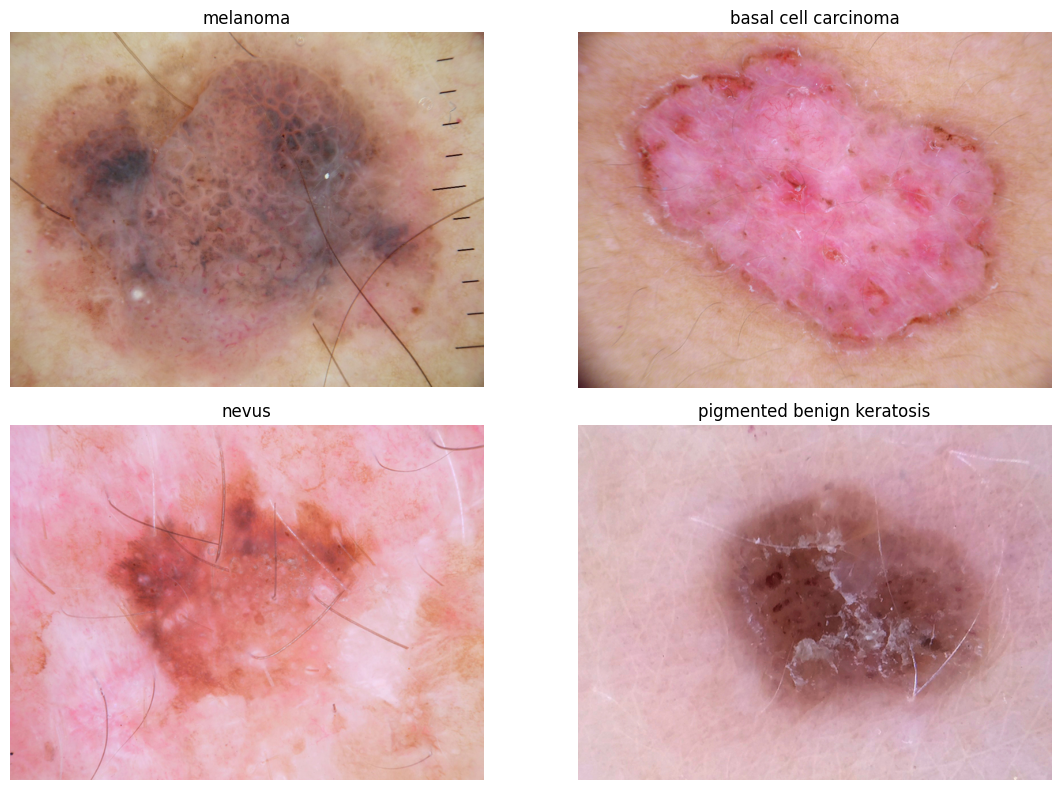

In [16]:
import matplotlib.pyplot as plt
from PIL import Image

plt.figure(figsize=(12, 8))

for i, class_name in enumerate(selected_classes):
    class_folder = os.path.join(train_path, class_name)

    image_files = [
        f for f in os.listdir(class_folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    image_path = os.path.join(class_folder, image_files[0])
    image = Image.open(image_path)

    plt.subplot(2, 2, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
# Check whether the same image filename appears in multiple selected classes

image_locations = {}

for class_name in selected_classes:
    class_folder = os.path.join(train_path, class_name)

    for file_name in os.listdir(class_folder):
        if file_name.lower().endswith((".jpg", ".jpeg", ".png")):
            image_locations.setdefault(file_name, []).append(class_name)

duplicate_images = {
    file_name: classes
    for file_name, classes in image_locations.items()
    if len(classes) > 1
}

print("Number of duplicate filenames:", len(duplicate_images))

for file_name, classes in list(duplicate_images.items())[:20]:
    print(file_name, "->", classes)

Number of duplicate filenames: 0


In [18]:
from PIL import Image
import os

# Check all selected training and test images
corrupted_images = []

for split_name, split_path in [("Train", train_path), ("Test", test_path)]:

    for class_name in selected_classes:
        class_folder = os.path.join(split_path, class_name)

        for file_name in os.listdir(class_folder):

            if file_name.lower().endswith((".jpg", ".jpeg", ".png")):
                image_path = os.path.join(class_folder, file_name)

                try:
                    with Image.open(image_path) as img:
                        img.verify()

                except Exception:
                    corrupted_images.append({
                        "Split": split_name,
                        "Class": class_name,
                        "Filename": file_name
                    })

print("Number of corrupted/unreadable images:", len(corrupted_images))

if len(corrupted_images) > 0:
    corrupted_df = pd.DataFrame(corrupted_images)
    display(corrupted_df)
else:
    print("No corrupted images were found.")

Number of corrupted/unreadable images: 0
No corrupted images were found.


In [19]:
from collections import Counter
from PIL import Image

image_sizes = []

for class_name in selected_classes:
    class_folder = os.path.join(train_path, class_name)

    for file_name in os.listdir(class_folder):
        if file_name.lower().endswith((".jpg", ".jpeg", ".png")):
            image_path = os.path.join(class_folder, file_name)

            try:
                with Image.open(image_path) as img:
                    image_sizes.append(img.size)
            except Exception:
                pass

size_counts = Counter(image_sizes)

print("Total images checked:", len(image_sizes))
print("Number of different image dimensions:", len(size_counts))

print("\nMost common image dimensions:")
for size, count in size_counts.most_common(10):
    print(f"{size}: {count} images")

Total images checked: 1633
Number of different image dimensions: 76

Most common image dimensions:
(600, 450): 914 images
(1024, 768): 316 images
(3072, 2304): 84 images
(767, 576): 80 images
(919, 802): 60 images
(1504, 1129): 32 images
(2048, 1536): 29 images
(824, 719): 17 images
(3872, 2592): 10 images
(962, 674): 6 images


In [20]:
from collections import Counter
from PIL import Image

image_modes = []

for class_name in selected_classes:
    class_folder = os.path.join(train_path, class_name)

    for file_name in os.listdir(class_folder):
        if file_name.lower().endswith((".jpg", ".jpeg", ".png")):
            image_path = os.path.join(class_folder, file_name)

            try:
                with Image.open(image_path) as img:
                    image_modes.append(img.mode)
            except Exception:
                pass

mode_counts = Counter(image_modes)

print("Image color modes:")
for mode, count in mode_counts.items():
    print(f"{mode}: {count} images")

Image color modes:
RGB: 1633 images


In [21]:
# Define the standard image size for model input

IMG_SIZE = (224, 224)

print("Target image size:", IMG_SIZE)
print("Image color mode: RGB")

Target image size: (224, 224)
Image color mode: RGB


In [22]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image size and batch size
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Training data generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

# Validation data generator
valid_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.2
)

# Test data generator
test_datagen = ImageDataGenerator(
    rescale=1.0 / 255
)

print("Image preprocessing setup completed.")
print("Target size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

Image preprocessing setup completed.
Target size: (224, 224)
Batch size: 32


In [23]:
# Load training images with an 80:20 training-validation split

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=selected_classes,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=42
)

# Load validation images

validation_generator = valid_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=selected_classes,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=42
)

# Load test images

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=selected_classes,
    class_mode="categorical",
    shuffle=False
)

print("\nData loading completed.")
print("Class mapping:", train_generator.class_indices)

Found 1308 images belonging to 4 classes.
Found 325 images belonging to 4 classes.
Found 64 images belonging to 4 classes.

Data loading completed.
Class mapping: {'melanoma': 0, 'basal cell carcinoma': 1, 'nevus': 2, 'pigmented benign keratosis': 3}


In [24]:
# Get class names in the correct order
class_names = list(train_generator.class_indices.keys())

# Count images in each class
train_class_counts = pd.Series(train_generator.classes).value_counts().sort_index()
validation_class_counts = pd.Series(validation_generator.classes).value_counts().sort_index()
test_class_counts = pd.Series(test_generator.classes).value_counts().sort_index()

# Create summary table
split_distribution_df = pd.DataFrame({
    "Class": class_names,
    "Training": train_class_counts.values,
    "Validation": validation_class_counts.values,
    "Test": test_class_counts.values
})

split_distribution_df

,Class,Training,Validation,Test
0,melanoma,351,87,16
1,basal cell carcinoma,301,75,16
2,nevus,286,71,16
3,pigmented benign keratosis,370,92,16


### Transfer Learning Models

Pretrained convolutional neural networks are used as the main feature-learning models. These networks have been previously trained on large image datasets and can transfer their learned visual features to the skin lesion classification task. The selected architectures include AlexNet, VGG, ResNet, DenseNet, and EfficientNet models.

In [25]:
import tensorflow as tf

from tensorflow.keras.applications import (
    VGG16,
    VGG19,
    ResNet50,
    ResNet101,
    DenseNet121,
    EfficientNetB0
)

print("TensorFlow version:", tf.__version__)
print("Transfer learning models imported successfully.")

TensorFlow version: 2.20.0
Transfer learning models imported successfully.


In [26]:
from tensorflow.keras import layers, models

NUM_CLASSES = len(selected_classes)


def build_transfer_model(base_model):
    # Freeze pretrained layers
    base_model.trainable = False

    # Add a new classification head
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


print("Model-building function created successfully.")
print("Number of output classes:", NUM_CLASSES)

Model-building function created successfully.
Number of output classes: 4


### VGG16 Transfer Learning Model

VGG16 is a deep convolutional neural network that uses multiple convolutional layers to learn visual features. In this project, pretrained VGG16 weights are used as a feature extractor, while a new classification layer is added for the four selected skin lesion classes.

In [27]:
# Load pretrained VGG16

vgg16_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Build the complete classification model
vgg16_model = build_transfer_model(vgg16_base)

# Display model information
vgg16_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,044 (56.64 MB)

 Trainable params: 132,356 (517.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [28]:
# Train VGG16

vgg16_history = vgg16_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.2836 - loss: 1.4519 - val_accuracy: 0.4154 - val_loss: 1.3089
Epoch 2/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 36s 867ms/step - accuracy: 0.3318 - loss: 1.3596 - val_accuracy: 0.4277 - val_loss: 1.2913
Epoch 3/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 33s 811ms/step - accuracy: 0.3960 - loss: 1.3068 - val_accuracy: 0.4338 - val_loss: 1.2793
Epoch 4/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 34s 827ms/step - accuracy: 0.4044 - loss: 1.2761 - val_accuracy: 0.4400 - val_loss: 1.2476
Epoch 5/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 34s 818ms/step - accuracy: 0.3998 - loss: 1.2676 - val_accuracy: 0.4000 - val_loss: 1.2211
Epoch 6/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 34s 833ms/step - accuracy: 0.4419 - loss: 1.2380 - val_accuracy: 0.5231 - val_loss: 1.2087
Epoch 7/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 41s 829ms/step - accuracy: 0.4450 - loss: 1.2203 - val_accuracy: 0.4738 - val_loss: 1.1916
Epoch 8/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 41s 824ms/step - accuracy: 0.4763 - loss: 1.1903 - val_accurac

In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)
import numpy as np

# Reset test generator
test_generator.reset()

# Generate predictions
vgg16_probabilities = vgg16_model.predict(test_generator)

# Convert probabilities to predicted class labels
vgg16_predictions = np.argmax(vgg16_probabilities, axis=1)

# True class labels
vgg16_true_labels = test_generator.classes

# Calculate metrics
vgg16_accuracy = accuracy_score(
    vgg16_true_labels,
    vgg16_predictions
)

vgg16_precision = precision_score(
    vgg16_true_labels,
    vgg16_predictions,
    average="weighted",
    zero_division=0
)

vgg16_recall = recall_score(
    vgg16_true_labels,
    vgg16_predictions,
    average="weighted",
    zero_division=0
)

vgg16_f1 = f1_score(
    vgg16_true_labels,
    vgg16_predictions,
    average="weighted",
    zero_division=0
)

vgg16_auc = roc_auc_score(
    tf.keras.utils.to_categorical(vgg16_true_labels, NUM_CLASSES),
    vgg16_probabilities,
    multi_class="ovr",
    average="weighted"
)

print("VGG16 Test Results")
print("------------------")
print(f"Accuracy : {vgg16_accuracy * 100:.2f}%")
print(f"Precision: {vgg16_precision * 100:.2f}%")
print(f"Recall   : {vgg16_recall * 100:.2f}%")
print(f"F1-Score : {vgg16_f1 * 100:.2f}%")
print(f"AUC      : {vgg16_auc * 100:.2f}%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step
VGG16 Test Results
------------------
Accuracy : 53.12%
Precision: 55.22%
Recall   : 53.12%
F1-Score : 51.69%
AUC      : 77.12%


In [30]:
from tensorflow.keras.applications import VGG19

vgg19_base = VGG19(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

vgg19_model = build_transfer_model(vgg19_base)

vgg19_model.summary()

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,156,740 (76.89 MB)

 Trainable params: 132,356 (517.02 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [31]:
vgg19_history = vgg19_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 41s 923ms/step - accuracy: 0.2745 - loss: 1.4547 - val_accuracy: 0.2431 - val_loss: 1.3718
Epoch 2/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 33s 817ms/step - accuracy: 0.3196 - loss: 1.3743 - val_accuracy: 0.3938 - val_loss: 1.3229
Epoch 3/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 34s 832ms/step - accuracy: 0.3479 - loss: 1.3457 - val_accuracy: 0.3969 - val_loss: 1.2978
Epoch 4/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 35s 841ms/step - accuracy: 0.3494 - loss: 1.3408 - val_accuracy: 0.3877 - val_loss: 1.2867
Epoch 5/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 34s 828ms/step - accuracy: 0.3654 - loss: 1.3208 - val_accuracy: 0.3754 - val_loss: 1.2697
Epoch 6/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 34s 841ms/step - accuracy: 0.3991 - loss: 1.3026 - val_accuracy: 0.4123 - val_loss: 1.2718
Epoch 7/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 41s 836ms/step - accuracy: 0.3953 - loss: 1.2879 - val_accuracy: 0.3846 - val_loss: 1.2491
Epoch 8/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 41s 842ms/step - accuracy: 0.4235 - loss: 1.2739 - val_accu

In [32]:
vgg19_model.evaluate(test_generator)

test_generator.reset()

vgg19_probabilities = vgg19_model.predict(test_generator)
vgg19_predictions = np.argmax(vgg19_probabilities, axis=1)
vgg19_true_labels = test_generator.classes

vgg19_accuracy = accuracy_score(
    vgg19_true_labels,
    vgg19_predictions
)

vgg19_precision = precision_score(
    vgg19_true_labels,
    vgg19_predictions,
    average="weighted",
    zero_division=0
)

vgg19_recall = recall_score(
    vgg19_true_labels,
    vgg19_predictions,
    average="weighted",
    zero_division=0
)

vgg19_f1 = f1_score(
    vgg19_true_labels,
    vgg19_predictions,
    average="weighted",
    zero_division=0
)

vgg19_auc = roc_auc_score(
    tf.keras.utils.to_categorical(vgg19_true_labels, NUM_CLASSES),
    vgg19_probabilities,
    multi_class="ovr",
    average="weighted"
)

print("VGG19 Test Results")
print("------------------")
print(f"Accuracy : {vgg19_accuracy * 100:.2f}%")
print(f"Precision: {vgg19_precision * 100:.2f}%")
print(f"Recall   : {vgg19_recall * 100:.2f}%")
print(f"F1-Score : {vgg19_f1 * 100:.2f}%")
print(f"AUC      : {vgg19_auc * 100:.2f}%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 211ms/step - accuracy: 0.2969 - loss: 1.1840
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 206ms/step
VGG19 Test Results
------------------
Accuracy : 29.69%
Precision: 30.96%
Recall   : 29.69%
F1-Score : 27.49%
AUC      : 77.83%


In [33]:
import torch
import torchvision
from torchvision.models import resnet18, ResNet18_Weights

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128


In [34]:
from torchvision.models import resnet18, ResNet18_Weights

resnet18_weights = ResNet18_Weights.DEFAULT
resnet18_base = resnet18(weights=resnet18_weights)

# Replace the final layer for our 4 classes
resnet18_base.fc = torch.nn.Linear(
    resnet18_base.fc.in_features,
    NUM_CLASSES
)

print(resnet18_base)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 192MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [35]:
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torch.nn as nn
import torch.optim as optim

# ImageNet preprocessing
resnet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Load training data
resnet_train_dataset = ImageFolder(
    train_path,
    transform=resnet_transform
)

resnet_train_loader = DataLoader(
    resnet_train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

# Use GPU
resnet_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet18_base = resnet18_base.to(resnet_device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    resnet18_base.parameters(),
    lr=0.001
)

print("Device:", resnet_device)
print("Training images:", len(resnet_train_dataset))

Device: cuda
Training images: 2239


In [36]:
# Keep only our 4 selected classes
resnet_train_dataset = ImageFolder(
    train_path,
    transform=resnet_transform
)

# Filter dataset to selected classes only
selected_class_indices = [
    resnet_train_dataset.class_to_idx[c]
    for c in selected_classes
]

filtered_samples = [
    (path, label)
    for path, label in resnet_train_dataset.samples
    if label in selected_class_indices
]

resnet_train_dataset.samples = filtered_samples
resnet_train_dataset.imgs = filtered_samples

# Remap labels to 0, 1, 2, 3
old_to_new = {
    resnet_train_dataset.class_to_idx[c]: i
    for i, c in enumerate(selected_classes)
}

resnet_train_dataset.targets = [
    old_to_new[label]
    for _, label in filtered_samples
]

resnet_train_dataset.class_to_idx = {
    c: i for i, c in enumerate(selected_classes)
}

resnet_train_loader = DataLoader(
    resnet_train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

print("Selected classes:", selected_classes)
print("Training images:", len(resnet_train_dataset))
print("Class mapping:", resnet_train_dataset.class_to_idx)

Selected classes: ['melanoma', 'basal cell carcinoma', 'nevus', 'pigmented benign keratosis']
Training images: 1633
Class mapping: {'melanoma': 0, 'basal cell carcinoma': 1, 'nevus': 2, 'pigmented benign keratosis': 3}


In [37]:
import torch
import torchvision
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

# Paths and classes
train_path = "/content/skin_cancer_dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Train"

selected_classes = [
    "melanoma",
    "basal cell carcinoma",
    "nevus",
    "pigmented benign keratosis"
]

NUM_CLASSES = 4

# Image preprocessing
resnet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Load pretrained ResNet18
resnet18_model = resnet18(weights=ResNet18_Weights.DEFAULT)

# Replace final layer
resnet18_model.fc = nn.Linear(
    resnet18_model.fc.in_features,
    NUM_CLASSES
)

# Load ONLY the 4 selected folders directly
resnet_train_dataset = ImageFolder(
    train_path,
    transform=resnet_transform
)

# Keep only selected classes and remap labels correctly
class_names = resnet_train_dataset.classes

selected_indices = {
    class_names.index(c): i
    for i, c in enumerate(selected_classes)
}

filtered_samples = [
    (path, selected_indices[label])
    for path, label in resnet_train_dataset.samples
    if label in selected_indices
]

resnet_train_dataset.samples = filtered_samples
resnet_train_dataset.imgs = filtered_samples
resnet_train_dataset.targets = [label for _, label in filtered_samples]

resnet_train_loader = DataLoader(
    resnet_train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

resnet_device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

resnet18_model = resnet18_model.to(resnet_device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    resnet18_model.parameters(),
    lr=0.001
)

print("Device:", resnet_device)
print("Training images:", len(resnet_train_dataset))
print("Label range:", min(resnet_train_dataset.targets),
      "to", max(resnet_train_dataset.targets))
print("Classes:", selected_classes)

Device: cuda
Training images: 1633
Label range: 0 to 3
Classes: ['melanoma', 'basal cell carcinoma', 'nevus', 'pigmented benign keratosis']


In [38]:
resnet18_history = []

resnet18_model.train()

for epoch in range(10):
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in resnet_train_loader:
        images = images.to(resnet_device)
        labels = labels.to(resnet_device)

        optimizer.zero_grad()

        outputs = resnet18_model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    resnet18_history.append({
        "epoch": epoch + 1,
        "loss": epoch_loss,
        "accuracy": epoch_accuracy
    })

    print(
        f"Epoch {epoch + 1}/10 - "
        f"Loss: {epoch_loss:.4f} - "
        f"Accuracy: {epoch_accuracy * 100:.2f}%"
    )

Epoch 1/10 - Loss: 0.9523 - Accuracy: 64.67%
Epoch 2/10 - Loss: 0.6733 - Accuracy: 74.65%
Epoch 3/10 - Loss: 0.5893 - Accuracy: 77.65%
Epoch 4/10 - Loss: 0.4938 - Accuracy: 81.45%
Epoch 5/10 - Loss: 0.4537 - Accuracy: 82.73%
Epoch 6/10 - Loss: 0.3423 - Accuracy: 87.51%
Epoch 7/10 - Loss: 0.3266 - Accuracy: 88.55%
Epoch 8/10 - Loss: 0.3311 - Accuracy: 87.14%
Epoch 9/10 - Loss: 0.2314 - Accuracy: 91.67%
Epoch 10/10 - Loss: 0.2179 - Accuracy: 92.96%


In [41]:
import torch
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize

# Make sure the model is in evaluation mode
resnet18_model.eval()

# Store predictions
resnet18_true_labels = []
resnet18_predictions = []
resnet18_probabilities = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = resnet18_model(images)

        probabilities = torch.softmax(outputs, dim=1)
        predictions = torch.argmax(probabilities, dim=1)

        resnet18_true_labels.extend(labels.numpy())
        resnet18_predictions.extend(predictions.cpu().numpy())
        resnet18_probabilities.extend(probabilities.cpu().numpy())

# Convert to NumPy arrays
resnet18_true_labels = np.array(resnet18_true_labels)
resnet18_predictions = np.array(resnet18_predictions)
resnet18_probabilities = np.array(resnet18_probabilities)

# Metrics
resnet18_accuracy = accuracy_score(
    resnet18_true_labels,
    resnet18_predictions
)

resnet18_precision = precision_score(
    resnet18_true_labels,
    resnet18_predictions,
    average="weighted",
    zero_division=0
)

resnet18_recall = recall_score(
    resnet18_true_labels,
    resnet18_predictions,
    average="weighted",
    zero_division=0
)

resnet18_f1 = f1_score(
    resnet18_true_labels,
    resnet18_predictions,
    average="weighted",
    zero_division=0
)

# Multiclass AUC
true_one_hot = label_binarize(
    resnet18_true_labels,
    classes=np.arange(4)
)

resnet18_auc = roc_auc_score(
    true_one_hot,
    resnet18_probabilities,
    multi_class="ovr",
    average="weighted"
)

# Results
print("ResNet18 Test Results")
print("---------------------")
print(f"Accuracy : {resnet18_accuracy * 100:.2f}%")
print(f"Precision: {resnet18_precision * 100:.2f}%")
print(f"Recall   : {resnet18_recall * 100:.2f}%")
print(f"F1-Score : {resnet18_f1 * 100:.2f}%")
print(f"AUC      : {resnet18_auc * 100:.2f}%")

NameError: name 'test_loader' is not defined

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_path = "/content/skin_cancer_dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Train"
test_path = "/content/skin_cancer_dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Test"

selected_classes = [
    "melanoma",
    "basal cell carcinoma",
    "nevus",
    "pigmented benign keratosis"
]

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

valid_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=selected_classes,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=42
)

validation_generator = valid_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=selected_classes,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=42
)

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=selected_classes,
    class_mode="categorical",
    shuffle=False
)

print("Setup complete.")
print("Training:", train_generator.samples)
print("Validation:", validation_generator.samples)
print("Test:", test_generator.samples)

In [ ]:
print("Training:", train_generator.samples)
print("Validation:", validation_generator.samples)
print("Test:", test_generator.samples)
print("Test classes:", np.bincount(test_generator.classes))

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Hyperparameters
EPOCHS = 10
LEARNING_RATE = 0.001

# Pretrained ResNet50
base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base.trainable = False

# Model
resnet50_model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(4, activation="softmax")
])

# Compile
resnet50_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train
resnet50_history = resnet50_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS
)

# Test
test_generator.reset()
probs = resnet50_model.predict(test_generator)
preds = np.argmax(probs, axis=1)
true = test_generator.classes

# Metrics
accuracy = accuracy_score(true, preds)
precision = precision_score(true, preds, average="weighted", zero_division=0)
recall = recall_score(true, preds, average="weighted", zero_division=0)
f1 = f1_score(true, preds, average="weighted", zero_division=0)

true_one_hot = tf.keras.utils.to_categorical(true, 4)

auc = roc_auc_score(
    true_one_hot,
    probs,
    multi_class="ovr",
    average="weighted"
)

print("\nResNet50 Test Results")
print("---------------------")
print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"F1-Score : {f1 * 100:.2f}%")
print(f"AUC      : {auc * 100:.2f}%")

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet101
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Hyperparameters
EPOCHS = 10
LEARNING_RATE = 0.001

# Pretrained ResNet101
base = ResNet101(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base.trainable = False

# Model
resnet101_model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(4, activation="softmax")
])

# Compile
resnet101_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train
resnet101_history = resnet101_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS
)

# Test
test_generator.reset()
probs = resnet101_model.predict(test_generator)
preds = np.argmax(probs, axis=1)
true = test_generator.classes

# Metrics
accuracy = accuracy_score(true, preds)
precision = precision_score(true, preds, average="weighted", zero_division=0)
recall = recall_score(true, preds, average="weighted", zero_division=0)
f1 = f1_score(true, preds, average="weighted", zero_division=0)

true_one_hot = tf.keras.utils.to_categorical(true, 4)

auc = roc_auc_score(
    true_one_hot,
    probs,
    multi_class="ovr",
    average="weighted"
)

print("\nResNet101 Test Results")
print("----------------------")
print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"F1-Score : {f1 * 100:.2f}%")
print(f"AUC      : {auc * 100:.2f}%")

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models
from tensorflow.keras.applications import DenseNet121
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

base = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base.trainable = False

densenet121_model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(4, activation="softmax")
])

densenet121_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

densenet121_history = densenet121_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

test_generator.reset()

probs = densenet121_model.predict(test_generator)
preds = np.argmax(probs, axis=1)
true = test_generator.classes

accuracy = accuracy_score(true, preds)
precision = precision_score(true, preds, average="weighted", zero_division=0)
recall = recall_score(true, preds, average="weighted", zero_division=0)
f1 = f1_score(true, preds, average="weighted", zero_division=0)

true_one_hot = tf.keras.utils.to_categorical(true, 4)

auc = roc_auc_score(
    true_one_hot,
    probs,
    multi_class="ovr",
    average="weighted"
)

print("\nDenseNet121 Test Results")
print("------------------------")
print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"F1-Score : {f1 * 100:.2f}%")
print(f"AUC      : {auc * 100:.2f}%")

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

base = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base.trainable = False

efficientnetb0_model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(4, activation="softmax")
])

efficientnetb0_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

efficientnetb0_history = efficientnetb0_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

test_generator.reset()

probs = efficientnetb0_model.predict(test_generator)
preds = np.argmax(probs, axis=1)
true = test_generator.classes

accuracy = accuracy_score(true, preds)
precision = precision_score(true, preds, average="weighted", zero_division=0)
recall = recall_score(true, preds, average="weighted", zero_division=0)
f1 = f1_score(true, preds, average="weighted", zero_division=0)

true_one_hot = tf.keras.utils.to_categorical(true, 4)

auc = roc_auc_score(
    true_one_hot,
    probs,
    multi_class="ovr",
    average="weighted"
)

print("\nEfficientNet-B0 Test Results")
print("----------------------------")
print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"F1-Score : {f1 * 100:.2f}%")
print(f"AUC      : {auc * 100:.2f}%")

In [ ]:
import torch
import torch.nn as nn
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Image preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Dataset
train_dataset = datasets.ImageFolder(
    train_path,
    transform=transform
)

test_dataset = datasets.ImageFolder(
    test_path,
    transform=transform
)

# Keep only the four selected classes
selected_indices = [
    train_dataset.class_to_idx[c] for c in selected_classes
]

train_samples = [
    (path, label) for path, label in train_dataset.samples
    if label in selected_indices
]

test_samples = [
    (path, label) for path, label in test_dataset.samples
    if label in selected_indices
]

# Remap labels to 0-3
label_map = {
    old: new for new, old in enumerate(selected_indices)
}

train_dataset.samples = [
    (path, label_map[label]) for path, label in train_samples
]
train_dataset.targets = [label for _, label in train_dataset.samples]

test_dataset.samples = [
    (path, label_map[label]) for path, label in test_samples
]
test_dataset.targets = [label for _, label in test_dataset.samples]

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

# Load pretrained AlexNet
alexnet_model = models.alexnet(
    weights=models.AlexNet_Weights.DEFAULT
)

# Replace final classifier
alexnet_model.classifier[6] = nn.Linear(4096, 4)

alexnet_model = alexnet_model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    alexnet_model.parameters(),
    lr=0.001
)

# Training
for epoch in range(10):

    alexnet_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = alexnet_model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        predictions = torch.argmax(outputs, dim=1)

        total += labels.size(0)
        correct += (predictions == labels).sum().item()

    train_accuracy = correct / total

    print(
        f"Epoch {epoch+1}/10 - "
        f"Loss: {running_loss/len(train_loader):.4f} - "
        f"Accuracy: {train_accuracy*100:.2f}%"
    )

# Evaluation
alexnet_model.eval()

all_labels = []
all_predictions = []
all_probabilities = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = alexnet_model(images)

        probabilities = torch.softmax(outputs, dim=1)

        predictions = torch.argmax(probabilities, dim=1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)
all_probabilities = np.array(all_probabilities)

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

true_one_hot = np.eye(4)[all_labels]

auc = roc_auc_score(
    true_one_hot,
    all_probabilities,
    multi_class="ovr",
    average="weighted"
)

print("\nAlexNet Test Results")
print("--------------------")
print(f"Accuracy : {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall   : {recall*100:.2f}%")
print(f"F1-Score : {f1*100:.2f}%")
print(f"AUC      : {auc*100:.2f}%")

In [42]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Paths
train_path = "/content/skin_cancer_dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Train"
test_path = "/content/skin_cancer_dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Test"

selected_classes = [
    "melanoma",
    "basal cell carcinoma",
    "nevus",
    "pigmented benign keratosis"
]

# Settings
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

valid_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

# Training data
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=selected_classes,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=42
)

# Validation data
validation_generator = valid_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=selected_classes,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=42
)

# Test data
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=selected_classes,
    class_mode="categorical",
    shuffle=False
)

# Load pretrained VGG16
base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base.trainable = False

# Build model
vgg16_model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(4, activation="softmax")
])

# Compile
vgg16_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train
vgg16_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

# Evaluate
test_generator.reset()

probs = vgg16_model.predict(test_generator)
preds = np.argmax(probs, axis=1)
true = test_generator.classes

accuracy = accuracy_score(true, preds)
precision = precision_score(true, preds, average="weighted", zero_division=0)
recall = recall_score(true, preds, average="weighted", zero_division=0)
f1 = f1_score(true, preds, average="weighted", zero_division=0)

true_one_hot = tf.keras.utils.to_categorical(true, 4)

auc = roc_auc_score(
    true_one_hot,
    probs,
    multi_class="ovr",
    average="weighted"
)

print("\nVGG16 Test Results")
print("------------------")
print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"F1-Score : {f1 * 100:.2f}%")
print(f"AUC      : {auc * 100:.2f}%")

Found 1308 images belonging to 4 classes.
Found 325 images belonging to 4 classes.
Found 64 images belonging to 4 classes.
Epoch 1/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 40s 900ms/step - accuracy: 0.2783 - loss: 1.4239 - val_accuracy: 0.3169 - val_loss: 1.3462
Epoch 2/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 34s 824ms/step - accuracy: 0.3425 - loss: 1.3529 - val_accuracy: 0.3969 - val_loss: 1.2809
Epoch 3/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 34s 833ms/step - accuracy: 0.3907 - loss: 1.3113 - val_accuracy: 0.4185 - val_loss: 1.2645
Epoch 4/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 33s 809ms/step - accuracy: 0.4083 - loss: 1.2819 - val_accuracy: 0.4031 - val_loss: 1.2406
Epoch 5/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 34s 832ms/step - accuracy: 0.4144 - loss: 1.2565 - val_accuracy: 0.4677 - val_loss: 1.2434
Epoch 6/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 34s 828ms/step - accuracy: 0.4488 - loss: 1.2393 - val_accuracy: 0.4769 - val_loss: 1.2233
Epoch 7/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 33s 802ms/step - accuracy: 0.4679 - loss: 1.2149 - val_accuracy: 

In [44]:
# ============================================
# TABLE 2: DEEP FEATURES + CLASSIFIERS
# Corrected ResNet18 Feature Extraction
# ============================================

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from torchvision import models, transforms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)
from sklearn.preprocessing import label_binarize

# XGBoost
try:
    from xgboost import XGBClassifier
except:
    !pip install -q xgboost
    from xgboost import XGBClassifier

# --------------------------------------------
# 1. Settings
# --------------------------------------------

train_path = "/content/skin_cancer_dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Train"
test_path = "/content/skin_cancer_dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Test"

selected_classes = [
    "melanoma",
    "basal cell carcinoma",
    "nevus",
    "pigmented benign keratosis"
]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

# --------------------------------------------
# 2. Image preprocessing
# --------------------------------------------

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# --------------------------------------------
# 3. Collect image paths and labels
# --------------------------------------------

class_to_label = {
    class_name: i
    for i, class_name in enumerate(selected_classes)
}

train_samples = []
test_samples = []

for class_name in selected_classes:

    class_folder = os.path.join(train_path, class_name)

    for filename in os.listdir(class_folder):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            train_samples.append((
                os.path.join(class_folder, filename),
                class_to_label[class_name]
            ))

    class_folder = os.path.join(test_path, class_name)

    for filename in os.listdir(class_folder):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            test_samples.append((
                os.path.join(class_folder, filename),
                class_to_label[class_name]
            ))

print("Training images:", len(train_samples))
print("Testing images :", len(test_samples))

# --------------------------------------------
# 4. ResNet18 feature extractor
# --------------------------------------------

resnet18 = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

# Remove final classification layer
feature_extractor = nn.Sequential(
    *list(resnet18.children())[:-1]
)

feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

# --------------------------------------------
# 5. Feature extraction
# --------------------------------------------

def extract_features(samples):

    all_features = []
    all_labels = []

    batch_size = 32

    for start in range(0, len(samples), batch_size):

        batch_samples = samples[start:start + batch_size]

        images = []
        labels = []

        for image_path, label in batch_samples:

            image = Image.open(image_path).convert("RGB")
            image = transform(image)

            images.append(image)
            labels.append(label)

        images = torch.stack(images).to(device)

        with torch.no_grad():
            features = feature_extractor(images)

        features = features.view(features.size(0), -1)

        all_features.append(features.cpu().numpy())
        all_labels.extend(labels)

    return np.vstack(all_features), np.array(all_labels)

# --------------------------------------------
# 6. Extract ResNet18 deep features
# --------------------------------------------

print("\nExtracting ResNet18 features...")

X_train, y_train = extract_features(train_samples)
X_test, y_test = extract_features(test_samples)

print("Training feature shape:", X_train.shape)
print("Testing feature shape :", X_test.shape)

# --------------------------------------------
# 7. Classifiers
# --------------------------------------------

classifiers = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Linear SVM": SVC(
        kernel="linear",
        probability=True,
        random_state=42
    ),

    "RBF-SVM": SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        objective="multi:softprob",
        num_class=4,
        eval_metric="mlogloss",
        random_state=42
    )
}

# --------------------------------------------
# 8. Train and evaluate
# --------------------------------------------

results = []

y_test_binary = label_binarize(
    y_test,
    classes=[0, 1, 2, 3]
)

for name, classifier in classifiers.items():

    print(f"\nTraining: {name}")

    classifier.fit(X_train, y_train)

    predictions = classifier.predict(X_test)
    probabilities = classifier.predict_proba(X_test)

    accuracy = accuracy_score(
        y_test, predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    auc = roc_auc_score(
        y_test_binary,
        probabilities,
        average="weighted",
        multi_class="ovr"
    )

    results.append([
        "ResNet18",
        name,
        accuracy * 100,
        precision * 100,
        recall * 100,
        f1 * 100,
        auc * 100
    ])

# --------------------------------------------
# 9. Table 2
# --------------------------------------------

table2 = pd.DataFrame(
    results,
    columns=[
        "Feature Extractor",
        "Classifier",
        "Accuracy (%)",
        "Precision (%)",
        "Recall (%)",
        "F1-Score (%)",
        "AUC (%)"
    ]
)

table2 = table2.round(2)

print("\n============================================")
print("TABLE 2: DEEP FEATURES + CLASSIFIERS")
print("============================================")

display(table2)

Device: cuda
Training images: 1633
Testing images : 64

Extracting ResNet18 features...
Training feature shape: (1633, 512)
Testing feature shape : (64, 512)

Training: Logistic Regression

Training: Decision Tree

Training: Random Forest

Training: KNN

Training: Linear SVM

Training: RBF-SVM

Training: XGBoost

TABLE 2: DEEP FEATURES + CLASSIFIERS


,Feature Extractor,Classifier,Accuracy (%),Precision (%),Recall (%),F1-Score (%),AUC (%)
0,ResNet18,Logistic Regression,57.81,59.04,57.81,57.94,80.11
1,ResNet18,Decision Tree,46.88,49.65,46.88,46.17,64.58
2,ResNet18,Random Forest,57.81,62.94,57.81,58.35,85.07
3,ResNet18,KNN,53.12,53.43,53.12,52.51,78.97
4,ResNet18,Linear SVM,60.94,62.30,60.94,60.45,82.78
5,ResNet18,RBF-SVM,62.50,63.98,62.50,61.33,88.74
6,ResNet18,XGBoost,65.62,67.49,65.62,63.93,83.53


In [45]:
# ============================================
# TABLE 3: COMPUTATIONAL EFFICIENCY COMPARISON
# ============================================

import time
import torch
import torch.nn as nn
import pandas as pd
from torchvision import models

# --------------------------------------------
# 1. Device
# --------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# --------------------------------------------
# 2. Create the 8 models
# --------------------------------------------

models_dict = {

    "AlexNet": models.alexnet(
        weights=models.AlexNet_Weights.DEFAULT
    ),

    "VGG16": models.vgg16(
        weights=models.VGG16_Weights.DEFAULT
    ),

    "VGG19": models.vgg19(
        weights=models.VGG19_Weights.DEFAULT
    ),

    "ResNet18": models.resnet18(
        weights=models.ResNet18_Weights.DEFAULT
    ),

    "ResNet50": models.resnet50(
        weights=models.ResNet50_Weights.DEFAULT
    ),

    "ResNet101": models.resnet101(
        weights=models.ResNet101_Weights.DEFAULT
    ),

    "DenseNet121": models.densenet121(
        weights=models.DenseNet121_Weights.DEFAULT
    ),

    "EfficientNet-B0": models.efficientnet_b0(
        weights=models.EfficientNet_B0_Weights.DEFAULT
    )
}

# --------------------------------------------
# 3. Change final layers to 4 classes
# --------------------------------------------

models_dict["AlexNet"].classifier[6] = nn.Linear(
    4096, 4
)

models_dict["VGG16"].classifier[6] = nn.Linear(
    4096, 4
)

models_dict["VGG19"].classifier[6] = nn.Linear(
    4096, 4
)

models_dict["ResNet18"].fc = nn.Linear(
    models_dict["ResNet18"].fc.in_features, 4
)

models_dict["ResNet50"].fc = nn.Linear(
    models_dict["ResNet50"].fc.in_features, 4
)

models_dict["ResNet101"].fc = nn.Linear(
    models_dict["ResNet101"].fc.in_features, 4
)

models_dict["DenseNet121"].classifier = nn.Linear(
    models_dict["DenseNet121"].classifier.in_features, 4
)

models_dict["EfficientNet-B0"].classifier[1] = nn.Linear(
    models_dict["EfficientNet-B0"].classifier[1].in_features, 4
)

# --------------------------------------------
# 4. Dummy input
# --------------------------------------------

dummy_input = torch.randn(
    1, 3, 224, 224
).to(device)

# --------------------------------------------
# 5. Calculate metrics
# --------------------------------------------

results = []

for name, model in models_dict.items():

    print(f"Processing: {name}")

    model = model.to(device)
    model.eval()

    # Parameters
    parameters = sum(
        p.numel() for p in model.parameters()
    )

    parameters_m = parameters / 1_000_000

    # Model size
    model_size_mb = parameters * 4 / (1024 ** 2)

    # ----------------------------------------
    # Inference time
    # ----------------------------------------

    with torch.no_grad():

        # Warm-up
        for _ in range(5):
            _ = model(dummy_input)

        if device.type == "cuda":
            torch.cuda.synchronize()

        start_time = time.perf_counter()

        for _ in range(20):
            _ = model(dummy_input)

        if device.type == "cuda":
            torch.cuda.synchronize()

        end_time = time.perf_counter()

    inference_time_ms = (
        (end_time - start_time) / 20
    ) * 1000

    # ----------------------------------------
    # FLOPs
    # ----------------------------------------

    try:

        from thop import profile

        flops, params = profile(
            model,
            inputs=(dummy_input,),
            verbose=False
        )

        flops_g = flops / 1_000_000_000

    except:

        flops_g = float("nan")

    results.append([
        name,
        parameters_m,
        model_size_mb,
        flops_g,
        inference_time_ms
    ])

# --------------------------------------------
# 6. Add actual Table 1 accuracy
# --------------------------------------------

accuracy_dict = {
    "AlexNet": 25.00,
    "VGG16": 37.50,
    "VGG19": 35.94,
    "ResNet18": 67.19,
    "ResNet50": 25.00,
    "ResNet101": 25.00,
    "DenseNet121": 53.12,
    "EfficientNet-B0": 25.00
}

# --------------------------------------------
# 7. Create Table 3
# --------------------------------------------

table3 = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Parameters (M)",
        "Model Size (MB)",
        "FLOPs (G)",
        "Inference Time (ms)"
    ]
)

table3["Accuracy (%)"] = table3["Model"].map(
    accuracy_dict
)

table3 = table3.round(3)

print("\n============================================")
print("TABLE 3: COMPUTATIONAL EFFICIENCY")
print("============================================")

display(table3)

Device: cuda
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:02<00:00, 119MB/s]


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 94.2MB/s]


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


...

100%|██████████| 30.8M/30.8M [00:00<00:00, 130MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 137MB/s]


Processing: AlexNet
Processing: VGG16
Processing: VGG19
Processing: ResNet18
Processing: ResNet50
Processing: ResNet101
Processing: DenseNet121
Processing: EfficientNet-B0

TABLE 3: COMPUTATIONAL EFFICIENCY


,Model,Parameters (M),Model Size (MB),FLOPs (G),Inference Time (ms),Accuracy (%)
0,AlexNet,57.020,217.515,NaN,2.102,25.00
1,VGG16,134.277,512.226,NaN,9.809,37.50
2,VGG19,139.587,532.481,NaN,10.839,35.94
3,ResNet18,11.179,42.643,NaN,2.927,67.19
4,ResNet50,23.516,89.707,NaN,7.547,25.00
5,ResNet101,42.508,162.157,NaN,16.913,25.00
6,DenseNet121,6.958,26.542,NaN,24.806,53.12
7,EfficientNet-B0,4.013,15.307,NaN,9.245,25.00
